## Localization of Connexin Plaques in 3D Image

1. Function to detect and label all seperate regions in the binary 3D mask 
2. Function to create a properties table from 3D regions with: center of region (x,y,z), region size, mean intensity 
3. Analysis of the regions in voxel and micrometer 

In [1]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
from skimage import io
import sys
sys.path.append(str(BASE_DIR / 'src'))
from localization import label_connexin_regions_3d, get_region_properties_3d
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# load the 3D binary_sauvola_21 image from 'data\segmented_images\binary_sauvola21_img_10_slides.tiff'
binary_sauvola_21_stack = io.imread(BASE_DIR / 'data/segmented/binary_sauvola2d_w21_k0_15.tiff')
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')
# match the 2_1 segmentation crop (z 60-500, x 23:999) so it aligns with the binary/labels
preprocessed_image = preprocessed_image[60:501, :, 23:999]

In [5]:
preprocessed_image.shape

(510, 2033, 1009)

In [6]:
binary_sauvola_21_stack.shape

(441, 2033, 976)

#### 1. Function to detect and label all seperate regions in the binary 3D mask 
#### 2. Function to create a properties table from 3D regions with: center of region (x,y,z), region size, mean intensity 

In [3]:
%time labeled_3d, n_components = label_connexin_regions_3d(binary_sauvola_21_stack, connectivity=1)

Labeling connected regions in 3D...
  Connected regions found: 36138
CPU times: user 6.01 s, sys: 2.67 s, total: 8.68 s
Wall time: 8.71 s


In [4]:
%time locations = get_region_properties_3d(labeled_3d, preprocessed_image, spacing=(0.766, 0.325, 0.325))

ValueError: Label and intensity image shapes must match, except for channel (last) axis.

In [6]:
# Saving the results 
io.imsave(BASE_DIR / 'data/localization_binary_masks/brightest_region_label_mask.tiff', labeled_3d)
locations.to_csv(BASE_DIR / 'data/localization_binary_masks/region_properties.csv', index=False)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/localization_binary_masks/brightest_region_label_mask.tiff is a low contrast image
  return func(*args, **kwargs)


In [7]:
locations.head()

,label,z,y,x,area_voxels,volume_um3,mean_intensity
0,1,0.000000,2.000000,77.000000,1.0,0.080909,302.744568
1,2,0.000000,3.000000,33.000000,1.0,0.080909,274.544220
2,3,19.899831,1001.269406,7.699455,586008.0,47413.174770,129.074692
3,4,0.000000,4.000000,65.000000,1.0,0.080909,282.169434
4,5,0.000000,5.000000,57.000000,1.0,0.080909,290.094238


### 3a Analysis for big image stack 

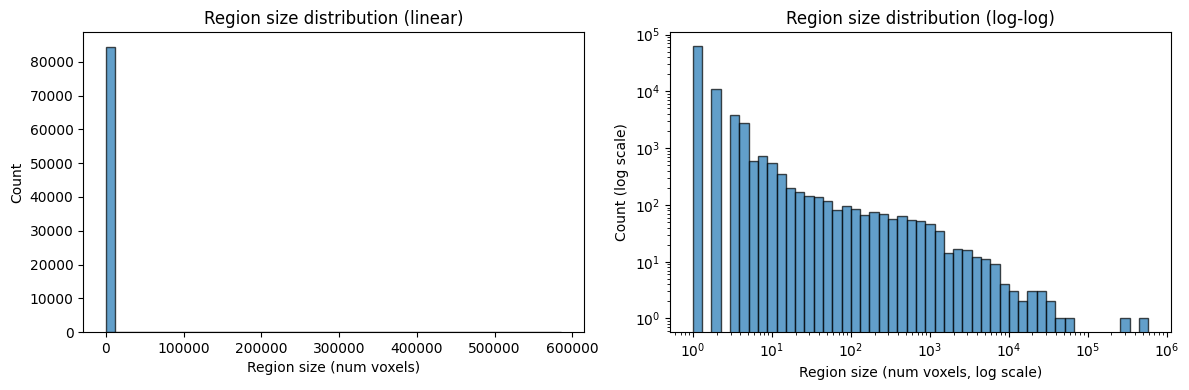

count     84513.000000
mean         23.109285
std        2250.511210
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max      586008.000000
Name: area_voxels, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['area_voxels'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (num voxels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
axes[1].hist(
    locations['area_voxels'],
    bins=np.logspace(0, np.log10(locations['area_voxels'].max()), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (num voxels, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print(locations['area_voxels'].describe())

### 3. Analysis of the regions in voxel and micrometer 

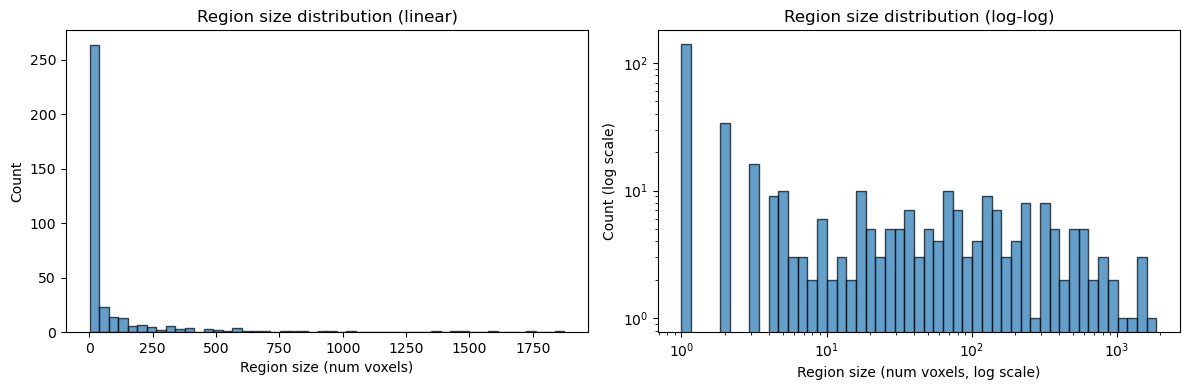

count     372.000000
mean       98.145161
std       251.017349
min         1.000000
25%         1.000000
50%         3.000000
75%        66.000000
max      1875.000000
Name: area_voxels, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['area_voxels'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (num voxels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
axes[1].hist(
    locations['area_voxels'],
    bins=np.logspace(0, np.log10(locations['area_voxels'].max()), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (num voxels, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print(locations['area_voxels'].describe())

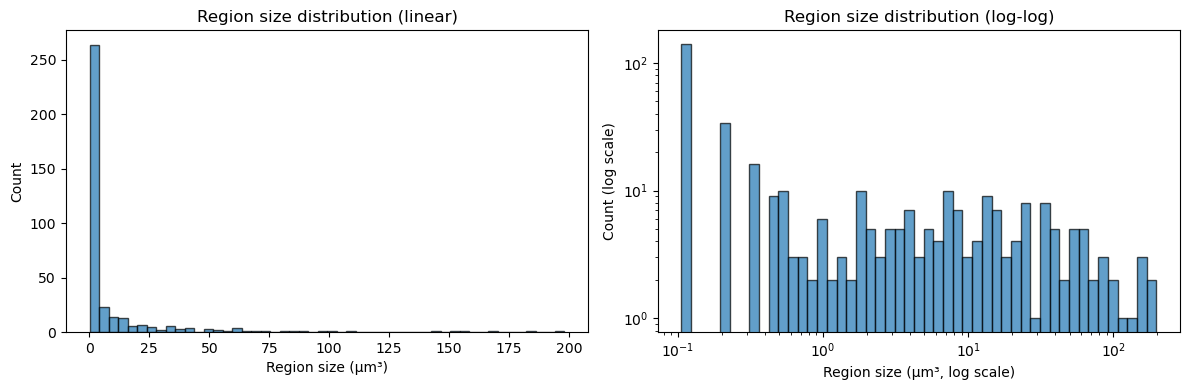

volume in µm³:
count    372.000000
mean      10.366583
std       26.513707
min        0.105625
25%        0.105625
50%        0.316875
75%        6.971250
max      198.046875
Name: volume_um3, dtype: float64
area in voxels:
count     372.000000
mean       98.145161
std       251.017349
min         1.000000
25%         1.000000
50%         3.000000
75%        66.000000
max      1875.000000
Name: area_voxels, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(locations['volume_um3'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Region size (µm³)')
axes[0].set_ylabel('Count')
axes[0].set_title('Region size distribution (linear)')

# Log-log scale, to see the full range including any long tail
min_val = locations['volume_um3'].min()
max_val = locations['volume_um3'].max()
axes[1].hist(
    locations['volume_um3'],
    bins=np.logspace(np.log10(min_val), np.log10(max_val), 50),
    edgecolor='black', alpha=0.7
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Region size (µm³, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Region size distribution (log-log)')

plt.tight_layout()
plt.show()

print('volume in µm³:')
print(locations['volume_um3'].describe())
print('area in voxels:')
print(locations['area_voxels'].describe())  # keep for cross-reference against voxel counts